### 0. Data Import from Kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"daffadanielrivaldi","key":"ca103f4f3f9913844b0ae4ea0ef3ff9a"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!pip install -q kaggle

In [ ]:
!kaggle competitions download -c playground-series-s4e9

  0% 0.00/7.84M [00:00<?, ?B/s]
100% 7.84M/7.84M [00:00<00:00, 680MB/s]


In [ ]:
!unzip playground-series-s4e9.zip -d playground-series-s4e9

Archive:  playground-series-s4e9.zip
  inflating: playground-series-s4e9/sample_submission.csv  
  inflating: playground-series-s4e9/test.csv  
  inflating: playground-series-s4e9/train.csv  


# 1. Exploratory Data Analysis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,TargetEncoder
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
df_train_full = pd.read_csv("/content/playground-series-s4e9/train.csv", index_col='id')
df_test = pd.read_csv("/content/playground-series-s4e9/test.csv", index_col='id')
df_sample_submission = pd.read_csv("/content/playground-series-s4e9/sample_submission.csv")

In [ ]:
df_train_full.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
id,,,,,,,,,,,,
0,MINI,Cooper S Base,2007,213000,Gasoline,172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,A/T,Yellow,Gray,None reported,Yes,4200
1,Lincoln,LS V8,2002,143250,Gasoline,252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel,A/T,Silver,Beige,At least 1 accident or damage reported,Yes,4999
2,Chevrolet,Silverado 2500 LT,2002,136731,E85 Flex Fuel,320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,Blue,Gray,None reported,Yes,13900
3,Genesis,G90 5.0 Ultimate,2017,19500,Gasoline,420.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,45000
4,Mercedes-Benz,Metris Base,2021,7388,Gasoline,208.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Beige,None reported,Yes,97500


## Data Definition

This dataset representing a unique vehicle listing, and includes nine distinct features providing valuable insights into the world of automobiles.

- Brand & Model: Identify the brand or company name along with the specific model of each vehicle.
- Model Year: Discover the manufacturing year of the vehicles, crucial for assessing depreciation and technology advancements.
- Mileage: Obtain the mileage of each vehicle, a key indicator of wear and tear and potential maintenance requirements.
- Fuel Type: Learn about the type of fuel the vehicles run on, whether it's gasoline, diesel, electric, or hybrid.
- Engine Type: Understand the engine specifications, shedding light on performance and efficiency.
- Transmission: Determine the transmission type, whether automatic, manual, or another variant.
- Exterior & Interior Colors: Explore the aesthetic aspects of the vehicles, including exterior and interior color options.
Accident History: Discover whether a vehicle has a prior history of accidents or damage, crucial for informed decision-making.
- Clean Title: Evaluate the availability of a clean title, which can impact the vehicle's resale value and legal status.
- Price: Access the listed prices for each vehicle, aiding in price comparison and budgeting.

## Descriptive Analysis

In [ ]:
df_train_full.shape

(188533, 12)

- Dataset memiliki 188.533 baris dan 13 kolom (dengan kolom 'id').

In [ ]:
df_train, df_valid = train_test_split(df_train_full, test_size=0.1, random_state=42)

- 10% dari data akan digunakan sebagai validation dataset.

In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 169679 entries, 32213 to 121958
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   brand         169679 non-null  object
 1   model         169679 non-null  object
 2   model_year    169679 non-null  int64 
 3   milage        169679 non-null  int64 
 4   fuel_type     165122 non-null  object
 5   engine        169679 non-null  object
 6   transmission  169679 non-null  object
 7   ext_col       169679 non-null  object
 8   int_col       169679 non-null  object
 9   accident      167470 non-null  object
 10  clean_title   150396 non-null  object
 11  price         169679 non-null  int64 
dtypes: int64(3), object(9)
memory usage: 16.8+ MB


In [ ]:
df_train.describe()

,model_year,milage,price
count,169679.000000,169679.000000,1.696790e+05
mean,2015.833615,65694.215083,4.388856e+04
std,5.654547,49764.734507,7.916143e+04
min,1974.000000,100.000000,2.000000e+03
25%,2013.000000,24213.000000,1.700000e+04
50%,2017.000000,57550.000000,3.089000e+04
75%,2020.000000,95400.000000,4.990000e+04
max,2024.000000,405000.000000,2.954083e+06


In [ ]:
df_train.describe(exclude='int64')

,brand,model,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title
count,169679,169679,165122,169679,169679,169679,169679,167470,150396
unique,57,1897,7,1117,52,319,156,2,1
top,Ford,F-150 XLT,Gasoline,355.0HP 5.3L 8 Cylinder Engine Gasoline Fuel,A/T,Black,Black,None reported,Yes
freq,20832,2658,149411,3133,44866,43742,96924,130134,150396


In [ ]:
df_train[df_train.duplicated(keep=False)]

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
id,,,,,,,,,,,,


Tidak ada duplikasi data

In [ ]:
df_train.isna().sum()

,0
brand,0
model,0
model_year,0
milage,0
fuel_type,4557
engine,0
transmission,0
ext_col,0
int_col,0
accident,2209


- Variabel `accident`, `clean_title`, dan `fuel_type` missing value yang harus ditangani.

## Univariate Analysis

In [ ]:
sns.set_theme()

### model_year

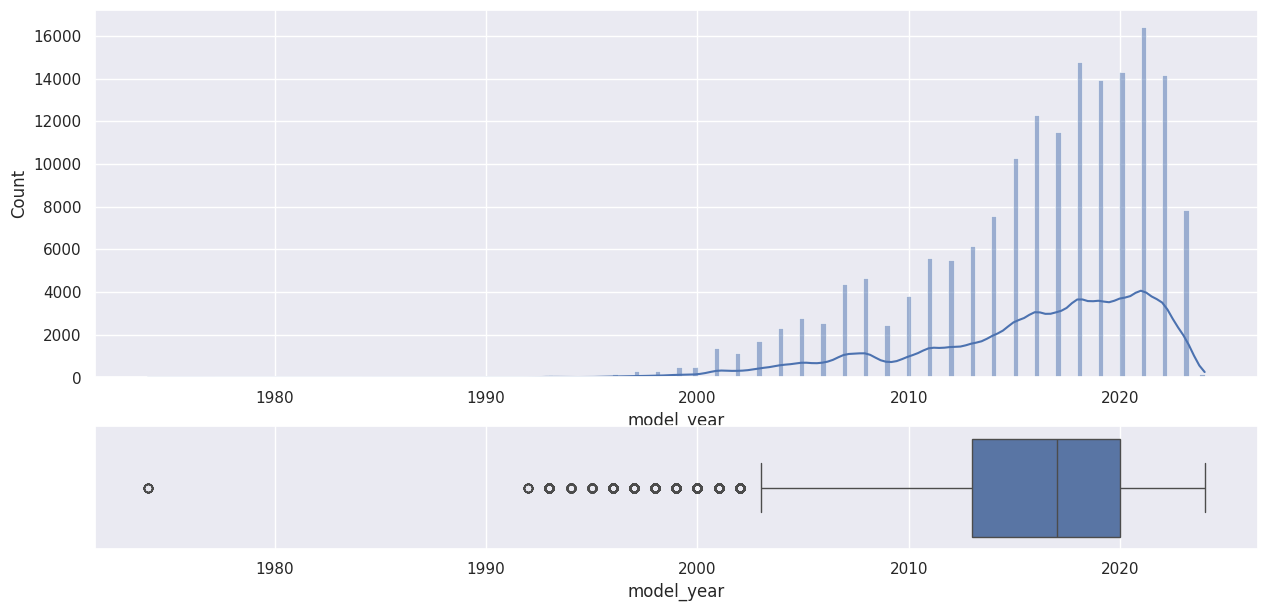

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(15, 7), gridspec_kw={'height_ratios': [3, 1]})
sns.histplot(data=df_train, x='model_year', kde=True, ax=axes[0])
sns.boxplot(x=df_train['model_year'], ax=axes[1])
plt.show()

- Sebagian besar mobil yang dijual adalah mobil keluaran tahun 2000 keatas.
- Variable `model_year` memiliki beberapa outlier yang perlu diselidiki lebih lanjut.

### Milage

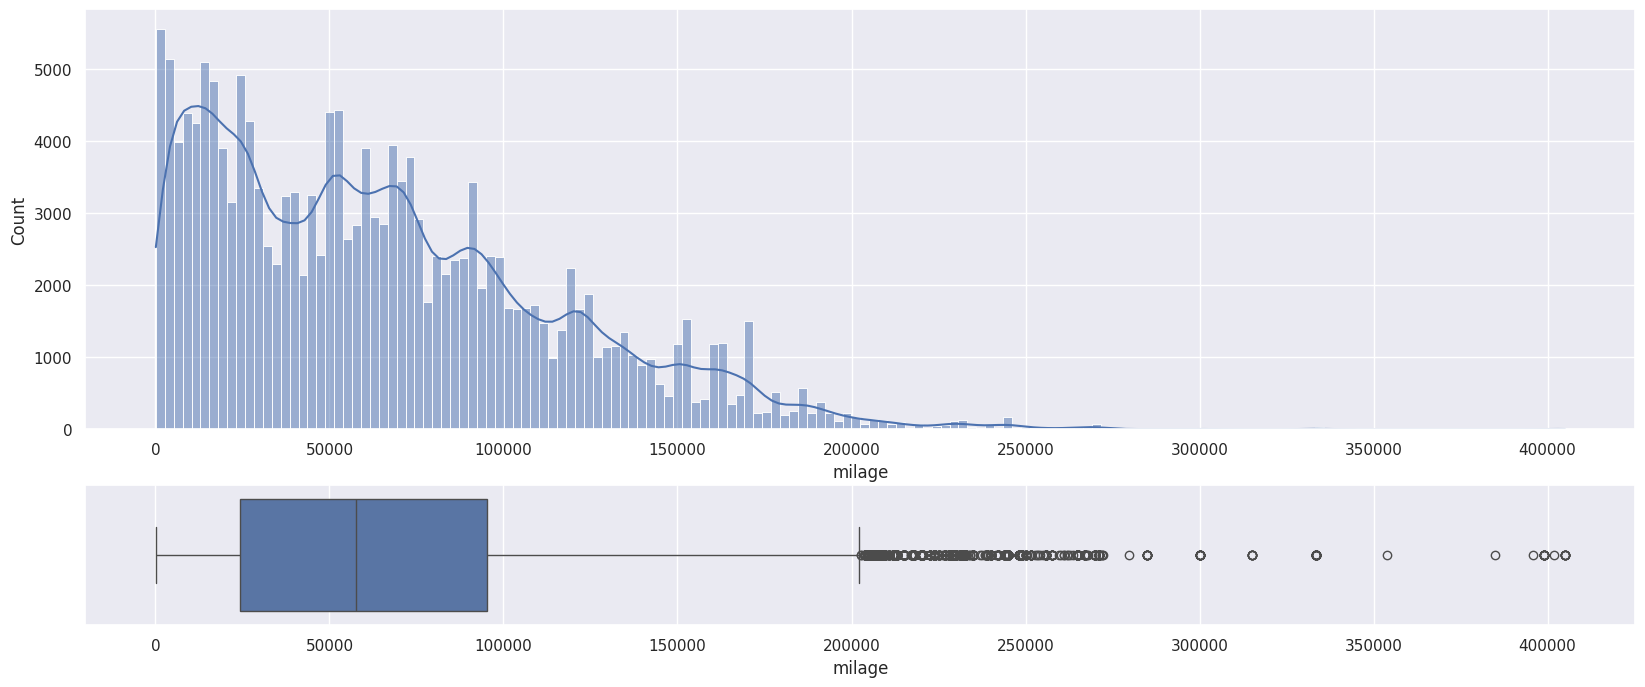

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(20, 8), gridspec_kw={'height_ratios': [3, 1]})
sns.histplot(data=df_train, x='milage', kde=True, ax=axes[0])
sns.boxplot(x=df_train['milage'], ax=axes[1])
plt.show()

- Variabel `milage` memiliki banyak outlier.
- Distribusinya positively skewed

### price

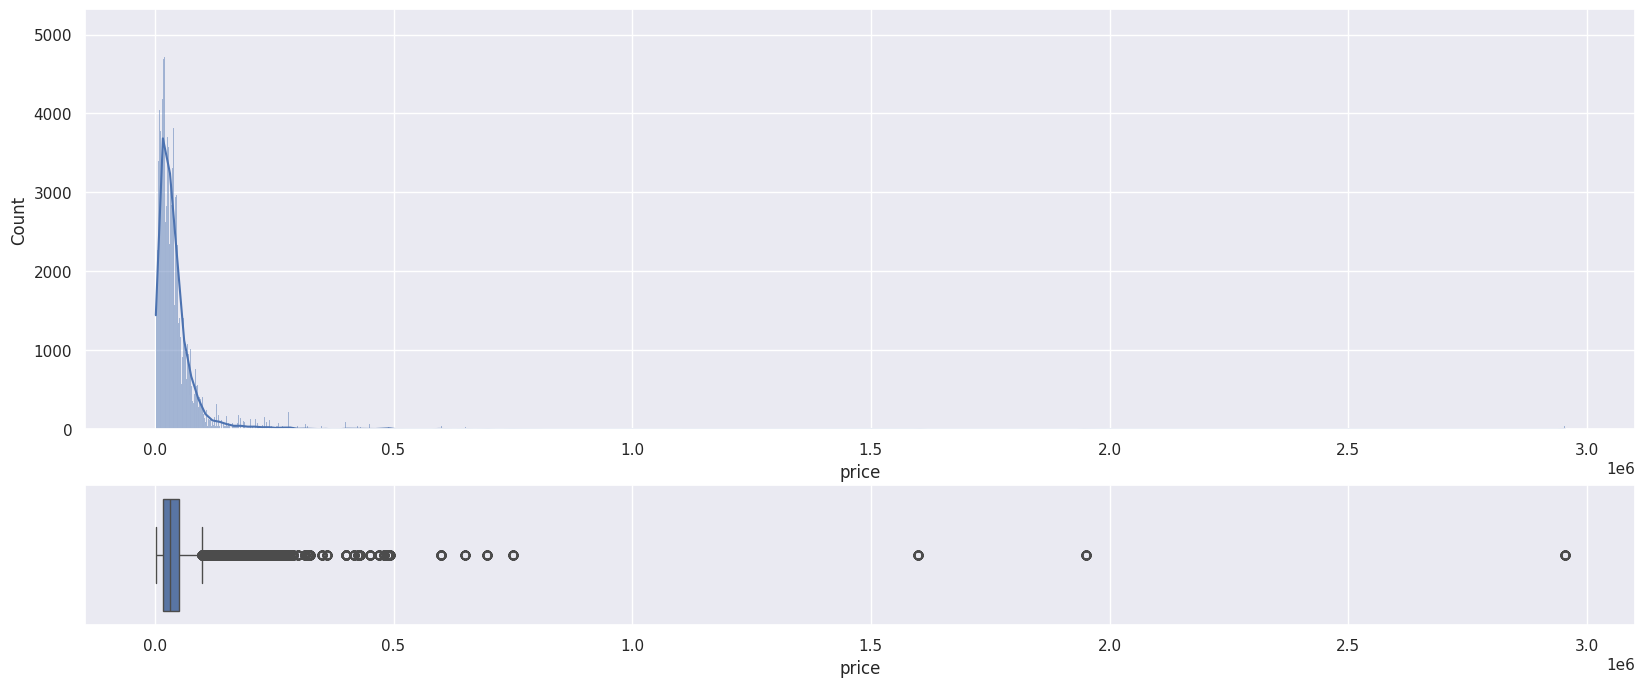

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(20, 8), gridspec_kw={'height_ratios': [3, 1]})
sns.histplot(data=df_train, x='price', kde=True, ax=axes[0])
sns.boxplot(x=df_train['price'], ax=axes[1])
plt.show()

- Variabel `price` memiliki banyak nilai outlier yang perlu diselidiki lebih lanjut.
- Beberapa Outlier berada sangat jauh dari Q4.

In [ ]:
Q1 = df_train['price'].quantile(0.25)
Q3 = df_train['price'].quantile(0.75)
IQR = Q3 - Q1
upper_whisker = Q3 + 1.5*IQR

outlier_id = df_train[df_train['price']> upper_whisker].index
df_outlier =df_train.loc[outlier_id]
df_outlier_1 = df_outlier[(df_outlier['price'] > upper_whisker) & (df_outlier['price'] < 500_000)]
df_outlier_2 = df_outlier[(df_outlier['price'] > 500_000) & (df_outlier['price'] < 1_000_000)]
df_outlier_3 = df_outlier[(df_outlier['price'] > 1_500_000) & (df_outlier['price'] < 2_000_000)]
df_outlier_4 = df_outlier[df_outlier['price'] > 2_500_000]
df_non_outlier = df_train.loc[~df_train.index.isin(outlier_id)]

In [ ]:
df_outlier_4.groupby(['brand','model','model_year']).apply(lambda x: x)

/tmp/ipython-input-2907124122.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_outlier_4.groupby(['brand','model','model_year']).apply(lambda x: x)


brand  \
brand         model                                              model_year id                      
Aston         Martin DB7 Vantage Volante                         2005       79469           Aston   
Audi          S4 Base                                            2004       18946            Audi   
Cadillac      DeVille Base                                       1994       181021       Cadillac   
              Escalade ESV Platinum                              2015       176936       Cadillac   
              Escalade Premium Luxury Platinum                   2021       138122       Cadillac   
              XT5 Luxury                                         2021       157056       Cadillac   
Chevrolet     Corvette Base                                      2005       66224       Chevrolet   
                                                                 2007       118167      Chevrolet   
              Silverado 1500 Custom Trail Boss                   2022       85611       Chevrolet   
              Tahoe LT                                           2018       46159       Chevrolet   
Chrysler      300C Base                                          2003       1880         Chrysler   
Dodge         Ram 2500 Laramie Quad Cab                          2005       103189          Dodge   
Ford          Bronco Raptor                                      2023       119162           Ford   
              Excursion Limited Ultimate                         2002       36615            Ford   
              Expedition Max King Ranch                          2021       89180            Ford   
              Expedition Max Limited                             2022       96473            Ford   
              Expedition Timberline                              2021       79269            Ford   
              F-150 XL                                           2022       81056            Ford   
              F-150 XLT                                          2021       220              Ford   
              Mustang GT                                         2005       42177            Ford   
              Thunderbird Deluxe                                 2008       151415           Ford   
GMC           Sierra 1500 SLE1 Extended Cab                      2020       80269             GMC   
Honda         Pilot Elite                                        2021       160629          Honda   
Hyundai       Santa Fe SEL                                       2022       14693         Hyundai   
INFINITI      QX60 Base                                          2017       129054       INFINITI   
Land          Rover LR4 Lux                                      2010       183006           Land   
              Rover Range Rover 3.0L V6 Supercharged HSE         2021       42219            Land   
              Rover Range Rover 5.0L Supercharged Autobiograp... 2017       67957            Land   
              Rover Range Rover P525 HSE SWB                     2020       99283            Land   
              Rover Range Rover Sport HST MHEV                   2022       163487           Land   
Lexus         LS 430 Base                                        2002       55493           Lexus   
                                                                 2004       55428           Lexus   
              SC 430 Base                                        2004       172766          Lexus   
Mercedes-Benz AMG GLE AMG GLE 63 S-Model 4MATIC                  2017       65043   Mercedes-Benz   
              AMG GT 53 Base                                     2023       84731   Mercedes-Benz   
              Metris Base                                        2020       74189   Mercedes-Benz   
              SL-Class SL500 Roadster                            2005       16034   Mercedes-Benz   
Pontiac       Firebird Trans Am                                  2001       97654         Pontiac   
RAM           1500 Classic Warlock                  

In [ ]:
df_outlier_4.groupby(['model','model_year'])['price'].agg(['count', 'mean', 'min', 'max'])

count  \
model                                              model_year          
1500 Classic Warlock                               2019            1   
1500 Laramie                                       2022            3   
1500 Limited                                       2018            1   
300C Base                                          2003            1   
AMG GLE AMG GLE 63 S-Model 4MATIC                  2017            1   
AMG GT 53 Base                                     2023            1   
Bronco Raptor                                      2023            1   
Corvette Base                                      2005            1   
                                                   2007            1   
DeVille Base                                       1994            1   
Escalade ESV Platinum                              2015            1   
Escalade Premium Luxury Platinum                   2021            1   
Excursion Limited Ultimate                         2002            1   
Expedition Max King Ranch                          2021            1   
Expedition Max Limited                             2022            1   
Expedition Timberline                              2021            1   
F-150 XL                                           2022            1   
F-150 XLT                                          2021            1   
Firebird Trans Am                                  2001            1   
Highlander XLE                                     2022            1   
LS 430 Base                                        2002            1   
                                                   2004            1   
Martin DB7 Vantage Volante                         2005            1   
Metris Base                                        2020            1   
Model 3 Long Range                                 2021            1   
Mustang GT                                         2005            1   
Pilot Elite                                        2021            1   
QX60 Base                                          2017            1   
Ram 2500 Laramie Quad Cab                          2005            1   
Rover LR4 Lux                                      2010            1   
Rover Range Rover 3.0L V6 Supercharged HSE         2021            1   
Rover Range Rover 5.0L Supercharged Autobiograp... 2017            1   
Rover Range Rover P525 HSE SWB                     2020            1   
Rover Range Rover Sport HST MHEV                   2022            1   
S4 Base                                            2004            1   
SC 430 Base                                        2004            1   
SL-Class SL500 Roadster                            2005            1   
Santa Fe SEL                                       2022            1   
Sierra 1500 SLE1 Extended Cab                      2020            1   
Silverado 1500 Custom Trail Boss                   2022            1   
Tahoe LT                                           2018            1   
Thunderbird Deluxe                                 2008            1   
XT5 Luxury                                         2021            1   

                                                                    mean  \
model                                              model_year              
1500 Classic Warlock                               2019        2954083.0   
1500 Laramie                                       2022        2954083.0   
1500 Limited                                       2018        2954083.0   
300C Base                                          2003        2954083.0   
AMG GLE AMG GLE 63 S-Model 4MATIC                  2017        2954083.0   
AMG GT 53 Base                                     2023        2954083.0   
Bronco Raptor                                      2023        2954083.0   
Corvette Base                                      2005        2954083.0   
                                                   2007       

In [ ]:
df_outlier_3.groupby(['brand','model','model_year']).apply(lambda x: x)

/tmp/ipython-input-2965682150.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_outlier_3.groupby(['brand','model','model_year']).apply(lambda x: x)


brand  \
brand       model               model_year id                    
Audi        A6 55 Premium Plus  2022       80820          Audi   
            A8 L 55             2021       148975         Audi   
BMW         M3 Base             2011       123868          BMW   
            M3 CS               2018       21523           BMW   
            M4 Base             2019       19118           BMW   
...                                                        ...   
RAM         3500 Tradesman      2023       84248           RAM   
Rolls-Royce Cullinan            2022       84816   Rolls-Royce   
            Ghost Base          2016       4164    Rolls-Royce   
                                2023       161053  Rolls-Royce   
Tesla       Model X Performance 2023       19379         Tesla   

                                                                 model  \
brand       model               model_year id                            
Audi        A6 55 Premium Plus  2022       80820    A6 55 Premium Plus   
            A8 L 55             2021       148975              A8 L 55   
BMW         M3 Base             2011       123868              M3 Base   
            M3 CS               2018       21523                 M3 CS   
            M4 Base             2019       19118               M4 Base   
...                                                                ...   
RAM         3500 Tradesman      2023       84248        3500 Tradesman   
Rolls-Royce Cullinan            2022       84816              Cullinan   
            Ghost Base          2016       4164             Ghost Base   
                                2023       161053           Ghost Base   
Tesla       Model X Performance 2023       19379   Model X Performance   

                                                   model_year  milage  \
brand       model               model_year id                           
Audi        A6 55 Premium Plus  2022       80820         2022   12209   
            A8 L 55             2021       148975        2021    1500   
BMW         M3 Base             2011       123868        2011   72277   
            M3 CS               2018       21523         2018    7500   
            M4 Base             2019       19118         2019   18000   
...                                                       ...     ...   
RAM         3500 Tradesman      2023       84248         2023    1750   
Rolls-Royce Cullinan            2022       84816         2022   17761   
            Ghost Base          2016       4164          2016   38800   
                                2023       161053        2023    5200   
Tesla       Model X Performance 2023       19379         2023     159   

                                                  fuel_type  \
brand       model               model_year id                 
Audi        A6 55 Premium Plus  2022       80820   Gasoline   
            A8 L 55             2021       148975    Hybrid   
BMW         M3 Base             2011       123868  Gasoline   
            M3 CS               2018       21523   Gasoline   
            M4 Base             2019       19118   Gasoline   
...                                                     ...   
RAM         3500 Tradesman      2023       84248     Diesel   
Rolls-Royce Cullinan            2022       84816   Gasoline   
            Ghost Base          2016       4164    Gasoline   
                                2023       161053  Gasoline   
Tesla       Model X Performance 2023       19379        NaN   

                                                                                              engine  \
brand       model               model_year id                                                          
Audi        A6 55 Premium Plus  2022       80820       335.0HP 3.0L V6 Cylinder Engine Gasoline Fuel   
            A8 L 55             2021       148975  335.0HP 3.0L V6 Cylinder Engine Gasoline/Mild ...   
BMW         M3 Base             2011       123868

In [ ]:
avg_price_outlier = df_outlier_4.groupby(['model', 'model_year'])['price'].agg(['mean', 'count'])
avg_price_outlier = avg_price_outlier.reset_index().rename(columns={'mean': 'outlier_avg_price', 'count': 'outlier_count'})

avg_price_non_outlier = df_non_outlier.groupby(['model', 'model_year'])['price'].agg(['mean','median', 'count'])
avg_price_non_outlier = avg_price_non_outlier.reset_index().rename(columns={'mean': 'non_outlier_avg_price','median':'non_outlier_median', 'count': 'non_outlier_count'})

combined_df = pd.merge(avg_price_outlier, avg_price_non_outlier, on=['model', 'model_year'], how='left')

print("Hasil Perbandingan:")
display(combined_df)

Hasil Perbandingan:


,model,model_year,outlier_avg_price,outlier_count,non_outlier_avg_price,non_outlier_median,non_outlier_count
0,1500 Classic Warlock,2019,2954083.0,1,38162.580000,37346.5,50.0
1,1500 Laramie,2022,2954083.0,3,49857.114679,46999.0,436.0
2,1500 Limited,2018,2954083.0,1,40449.925926,39750.0,27.0
3,300C Base,2003,2954083.0,1,NaN,NaN,NaN
4,AMG GLE AMG GLE 63 S-Model 4MATIC,2017,2954083.0,1,45563.192308,41500.0,26.0
5,AMG GT 53 Base,2023,2954083.0,1,85280.714286,85495.0,7.0
6,Bronco Raptor,2023,2954083.0,1,70219.684211,69790.0,19.0
7,Corvette Base,2005,2954083.0,1,19505.266667,13900.0,105.0
8,Corvette Base,2007,2954083.0,1,28063.925287,19850.0,174.0
9,DeVille Base,1994,2954083.0,1,16852.352941,10000.0,17.0


In [ ]:

avg_price_outlier = df_outlier.groupby(['model', 'model_year'])['price'].agg(['mean', 'count'])
avg_price_outlier = avg_price_outlier.reset_index().rename(columns={'mean': 'outlier_avg_price', 'count': 'outlier_count'})

avg_price_non_outlier = df_non_outlier.groupby(['model', 'model_year'])['price'].agg(['mean', 'count'])
avg_price_non_outlier = avg_price_non_outlier.reset_index().rename(columns={'mean': 'non_outlier_avg_price', 'count': 'non_outlier_count'})

combined_df = pd.merge(avg_price_outlier, avg_price_non_outlier, on=['model', 'model_year'], how='left')

print("Hasil Perbandingan:")
display(combined_df)

Hasil Perbandingan:


,model,model_year,outlier_avg_price,outlier_count,non_outlier_avg_price,non_outlier_count
0,135 i,2009,102000.0,1,13980.875000,16.0
1,1500 Big Horn,2013,229900.0,1,40231.666667,3.0
2,1500 Big Horn,2014,229000.0,1,20643.600000,20.0
3,1500 Big Horn,2015,154900.0,1,26717.722222,18.0
4,1500 Big Horn,2016,243900.0,1,22475.454545,11.0
...,...,...,...,...,...,...
3327,Yukon XL SLT,2023,112500.0,1,66396.647059,17.0
3328,Z4 sDrive35is,2015,112500.0,1,25133.333333,3.0
3329,e-tron Prestige,2021,171900.0,1,34832.600000,5.0
3330,i8 Base,2021,103000.0,1,48749.750000,4.0


### Brand

In [ ]:
df_train['brand'].value_counts()

,count
brand,
Ford,20832
Mercedes-Benz,17313
BMW,15304
Chevrolet,14716
Audi,9772
Porsche,9523
Land,8547
Toyota,7967
Lexus,7729


In [ ]:
np.sort(df_train['brand'].unique())

array(['Acura', 'Alfa', 'Aston', 'Audi', 'BMW', 'Bentley', 'Bugatti',
       'Buick', 'Cadillac', 'Chevrolet', 'Chrysler', 'Dodge', 'FIAT',
       'Ferrari', 'Ford', 'GMC', 'Genesis', 'Honda', 'Hummer', 'Hyundai',
       'INFINITI', 'Jaguar', 'Jeep', 'Karma', 'Kia', 'Lamborghini',
       'Land', 'Lexus', 'Lincoln', 'Lotus', 'Lucid', 'MINI', 'Maserati',
       'Maybach', 'Mazda', 'McLaren', 'Mercedes-Benz', 'Mercury',
       'Mitsubishi', 'Nissan', 'Plymouth', 'Polestar', 'Pontiac',
       'Porsche', 'RAM', 'Rivian', 'Rolls-Royce', 'Saab', 'Saturn',
       'Scion', 'Subaru', 'Suzuki', 'Tesla', 'Toyota', 'Volkswagen',
       'Volvo', 'smart'], dtype=object)

- Tidak terdapat kesalahan nama pada variabel `brand`.

### Model

In [ ]:
df_train['model'].value_counts()

,count
model,
F-150 XLT,2658
M3 Base,2036
Camaro 2SS,1523
M4 Base,1452
Mustang GT Premium,1386
...,...
X5 3.0i,1
X5 xDrive 35i Sport Activity,1
XLR Base,1


- Terdapat 1897 model mobil

### Fuel Type

In [ ]:
df_train['fuel_type'].unique()

array(['Gasoline', nan, 'Diesel', 'Hybrid', 'E85 Flex Fuel', '–',
       'Plug-In Hybrid', 'not supported'], dtype=object)

In [ ]:
df_train['fuel_type'].value_counts()

,count
fuel_type,
Gasoline,149411
Hybrid,6139
E85 Flex Fuel,4876
Diesel,3511
–,698
Plug-In Hybrid,474
not supported,13


In [ ]:
df_train[df_train['fuel_type'] =='not supported']

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
id,,,,,,,,,,,,
140206,Lexus,RX 330 Base,2006,110000,not supported,230.0HP 3.3L V6 Cylinder Engine Gasoline Fuel,5-Speed A/T,White,Beige,At least 1 accident or damage reported,Yes,9500
171659,Toyota,Mirai Limited,2021,44000,not supported,182.0HP Electric Motor Hydrogen Fuel,A/T,Gray,Black,None reported,Yes,4900
4823,Chevrolet,Suburban LT,2011,109646,not supported,320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,6-Speed A/T,Black,Beige,None reported,Yes,18998
128917,Mazda,MX-5 Miata Base,1999,120000,not supported,140.0HP 1.8L 4 Cylinder Engine Gasoline Fuel,5-Speed M/T,Black,Beige,At least 1 accident or damage reported,Yes,4000
18000,Porsche,Camaro 2SS,2015,67000,not supported,240.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,11500
19182,Nissan,Mirai Limited,2000,131000,not supported,182.0HP Electric Motor Hydrogen Fuel,A/T,Silver,Black,None reported,Yes,5000
33030,Nissan,Mirai Limited,2009,137333,not supported,182.0HP Electric Motor Hydrogen Fuel,A/T,White,Gray,At least 1 accident or damage reported,Yes,12999
60717,Chevrolet,Silverado 1500 RST,2020,19200,not supported,355.0HP 5.3L 8 Cylinder Engine Gasoline Fuel,10-Speed A/T,White,Black,At least 1 accident or damage reported,Yes,58000
86897,Lexus,IS 350 F Sport,2022,9500,not supported,311.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,A/T,Gray,Black,None reported,Yes,60000


- Variabel `fuel_type` memiliki missing value yang tersimpan sebagai `-`,`not supported` dan`nan` serta perlu ditambahkan kategori '`hydro fuel`.
- 'E85 flex fuel' perlu diseragamkan menjadi 'flex fuel'

### Engine

In [ ]:
pd.DataFrame(df_train['engine'].unique())

,0
0,315.0HP 2.7L V6 Cylinder Engine Gasoline Fuel
1,563.0HP 5.5L 8 Cylinder Engine Gasoline Fuel
2,480.0HP Electric Motor Electric Fuel System
3,543.0HP 3.0L Straight 6 Cylinder Engine Gasoli...
4,190.0HP 4.3L V6 Cylinder Engine Gasoline Fuel
...,...
1112,443.0HP 4.4L 8 Cylinder Engine Gasoline Fuel
1113,184.0HP 2.4L 4 Cylinder Engine Flex Fuel Capab...
1114,313.0HP 2.0L 4 Cylinder Engine Plug-In Electri...
1115,78.0HP 1.2L 3 Cylinder Engine Gasoline Fuel


In [ ]:
mask = ~df_train['engine'].str.contains('cylinder', case=False, na=False)

In [ ]:
df_train.loc[mask, 'engine'].unique()

array(['480.0HP Electric Motor Electric Fuel System',
       '6.5L V12 48V MPFI DOHC', '3.5L V6 24V GDI SOHC', '6.4 Liter',
       '5.6L V8 32V GDI DOHC', '5.3L V8 16V GDI OHV',
       '2.5L I4 16V GDI DOHC Turbo', '2.0L I4 16V GDI DOHC Turbo',
       '4.0L V8 32V GDI DOHC Twin Turbo', '2.0L I4 16V GDI SOHC Turbo',
       '2.4L I4 16V GDI DOHC', '3.6L V6 24V MPFI DOHC', '–',
       'Electric Motor Electric Fuel System',
       '375.0HP Electric Motor Electric Fuel System',
       '3.5L V6 24V PDI DOHC Twin Turbo', '3.6L V6 24V GDI DOHC',
       '3.0 Liter', '4.4L V8 32V GDI DOHC Twin Turbo', '3.5 Liter',
       '4.0 Liter TFSI', '346.0HP Electric Motor Electric Fuel System',
       '6.2L V8 16V MPFI SOHC Flexible Fuel', '4.0L H6 24V GDI DOHC',
       '5.7L V8 16V MPFI OHV', '3.5L V6 24V PDI DOHC', '2.0 Liter',
       '518.0HP Electric Motor Electric Fuel System',
       '5.0L V8 32V GDI DOHC Supercharged', '1.5L I3 12V PDI DOHC Turbo',
       '3.3L V6 24V GDI DOHC', '1.5L I4 16V GDI DO

In [ ]:
df_copy = df_train.copy()

In [ ]:
df_copy['engine_word_count'] = df_copy['engine'].astype(str).str.split().str.len()

In [ ]:
df_copy['engine_word_count'].unique()

array([7, 6, 8, 5, 2, 1, 9, 3, 4])

In [ ]:
df_copy[df_copy['engine_word_count']==1]['engine'].unique()

array(['–', 'I4', 'Electric', '3.0L', 'V6', '4.0L', 'V8', '2.5L'],
      dtype=object)

In [ ]:
df_copy[df_copy['engine_word_count']==2]['engine'].unique()

array(['6.4 Liter', '3.0 Liter', '3.5 Liter', '2.0 Liter', '5.6 Liter',
       '5.5 Liter', '4.6 Liter', '5.0 Liter', '4.0 Liter', '3.6 Liter',
       '4.4 Liter', '2.5 Liter', '6.2 Liter', '2.4 Liter', '5.3 Liter',
       '1.8 Liter', '5.7 Liter', '5.4 Liter', '120 AH',
       'Battery Electric'], dtype=object)

In [ ]:
df_copy[df_copy['engine_word_count']==3]['engine'].unique()

array(['4.0 Liter TFSI', '3.0 Liter TFSI', '3.0 Liter Turbo',
       '2.0 Liter Turbo', '2.0 Liter TFSI', 'Standard Range Battery',
       '3.0 Liter GTDI', '3.5 Liter DOHC', '2.9 Liter Turbo',
       '4.0 Liter Turbo', '5.0L 8 Cylinder', '2.5L I4 16V',
       '3.5 Liter GTDI', '3.5 Liter SOHC', '2.0 Liter TSI',
       '3.6 Liter DOHC', '12 Cylinder Engine', '1.5 Liter Turbo',
       '2.0 Liter Supercharged'], dtype=object)

In [ ]:
df_copy[df_copy['engine_word_count']==4]['engine'].unique()

array(['4.4 Liter Twin Turbo', 'Dual Motor - Standard',
       '2.0 Liter DOHC Turbo', '3.0 Liter DOHC Turbo',
       '4.0 Liter Twin Turbo', '5.4 Liter SC DOHC',
       '3.0 Liter Twin Turbo', '2.0 Liter DOHC T/C',
       '3.6 Liter SIDI DOHC', '2.7 Liter DOHC Turbo',
       '4.7 Liter Twin Turbo', 'Dual AC Electric Motors',
       '6.6 Liter Twin Turbo', '3.6L V6 GDI DOHC', '3.0 Liter SC ULEV'],
      dtype=object)

In [ ]:
df_copy[df_copy['engine_word_count']==5]['engine'].unique()

array(['6.5L V12 48V MPFI DOHC', '3.5L V6 24V GDI SOHC',
       '5.6L V8 32V GDI DOHC', '5.3L V8 16V GDI OHV',
       '2.4L I4 16V GDI DOHC', '3.6L V6 24V MPFI DOHC',
       'Electric Motor Electric Fuel System', '3.6L V6 24V GDI DOHC',
       '4.0L H6 24V GDI DOHC', '5.7L V8 16V MPFI OHV',
       '3.5L V6 24V PDI DOHC', '3.3L V6 24V GDI DOHC',
       '4.4 Liter DOHC Twin Turbo', '5.2L V10 40V GDI DOHC',
       '6.2L V8 16V GDI OHV', '2.5L I4 16V GDI DOHC',
       '5.0L V8 32V PDI DOHC', '6.6L V8 16V GDI OHV',
       '4.0L V6 24V MPFI DOHC', '4.6L V8 32V MPFI DOHC',
       '4.2L V8 32V GDI DOHC', '2.0L I4 16V MPFI DOHC',
       '3.5L V6 24V MPFI DOHC', '2.4L I4 16V MPFI DOHC',
       '2.5L I4 16V PDI DOHC', '2.5L H4 16V GDI DOHC',
       '6.4L V8 16V MPFI OHV', '5.2L V10 40V PDI DOHC',
       '3.8L H6 24V MPFI DOHC', '2.0L I4 16V GDI DOHC',
       '151.0HP Electric Motor Hydrogen Fuel', '2.5L I4 16V MPFI DOHC',
       '3.8L V6 24V GDI DOHC', '1.6L I4 16V MPFI DOHC',
       '3.0 Liter D

In [ ]:
df_copy[df_copy['engine_word_count']==6]['engine'].unique()

array(['480.0HP Electric Motor Electric Fuel System',
       '2.5L I4 16V GDI DOHC Turbo', '2.0L I4 16V GDI DOHC Turbo',
       '2.0L I4 16V GDI SOHC Turbo',
       '375.0HP Electric Motor Electric Fuel System',
       '346.0HP Electric Motor Electric Fuel System',
       '518.0HP Electric Motor Electric Fuel System',
       '5.0L V8 32V GDI DOHC Supercharged', '1.5L I3 12V PDI DOHC Turbo',
       '1.5L I4 16V GDI DOHC Turbo', '3.0L I6 24V GDI DOHC Turbo',
       '557.0HP Electric Motor Electric Fuel System',
       '271.0HP Electric Motor Electric Fuel System',
       '534.0HP Electric Motor Electric Fuel System',
       '2.3L I4 16V GDI DOHC Turbo',
       '320.0HP Electric Motor Electric Fuel System',
       '3.5L V6 24V PDI DOHC Hybrid',
       '417.0HP Electric Motor Electric Fuel System',
       '563.0HP Electric Motor Electric Fuel System',
       '2.0L I4 16V MPFI DOHC Hybrid',
       '425.0HP Electric Motor Electric Fuel System',
       '455.0HP Electric Motor Electric Fuel Sy

In [ ]:
df_copy[df_copy['engine_word_count']==7]['engine'].unique()

array(['315.0HP 2.7L V6 Cylinder Engine Gasoline Fuel',
       '563.0HP 5.5L 8 Cylinder Engine Gasoline Fuel',
       '190.0HP 4.3L V6 Cylinder Engine Gasoline Fuel',
       '382.0HP 5.5L 8 Cylinder Engine Gasoline Fuel',
       '463.0HP 4.0L 8 Cylinder Engine Gasoline Fuel',
       '523.0HP 4.4L 8 Cylinder Engine Gasoline Fuel',
       '325.0HP 6.0L 8 Cylinder Engine Diesel Fuel',
       '262.0HP 3.5L V6 Cylinder Engine Gasoline Fuel',
       '302.0HP 5.0L 8 Cylinder Engine Gasoline Fuel',
       '302.0HP 3.5L V6 Cylinder Engine Gasoline Fuel',
       '424.0HP 3.0L V6 Cylinder Engine Gasoline Fuel',
       '310.0HP 2.3L 4 Cylinder Engine Gasoline Fuel',
       '208.0HP 2.0L 4 Cylinder Engine Gasoline Fuel',
       '288.0HP 3.6L V6 Cylinder Engine Gasoline Fuel',
       '263.0HP 4.7L 8 Cylinder Engine Gasoline Fuel',
       '563.0HP 6.7L 12 Cylinder Engine Gasoline Fuel',
       '360.0HP 4.8L 8 Cylinder Engine Gasoline Fuel',
       '335.0HP 4.7L 8 Cylinder Engine Gasoline Fuel',
     

In [ ]:
df_copy[df_copy['engine_word_count']==8]['engine'].unique()

array(['543.0HP 3.0L Straight 6 Cylinder Engine Gasoline Fuel',
       '333.0HP 3.2L Straight 6 Cylinder Engine Gasoline Fuel',
       '503.0HP 3.0L Straight 6 Cylinder Engine Gasoline Fuel',
       '603.0HP 4.0L 8 Cylinder Engine Gasoline/Mild Electric Hybrid',
       '385.0HP 6.2L 8 Cylinder Engine Flex Fuel Capability',
       '350.0HP 3.4L Flat 6 Cylinder Engine Gasoline Fuel',
       '283.0HP 3.6L V6 Cylinder Engine Flex Fuel Capability',
       '335.0HP 3.0L V6 Cylinder Engine Gasoline/Mild Electric Hybrid',
       '315.0HP 3.6L Flat 6 Cylinder Engine Gasoline Fuel',
       '300.0HP 3.0L Straight 6 Cylinder Engine Gasoline Fuel',
       '403.0HP 6.2L 8 Cylinder Engine Flex Fuel Capability',
       '425.0HP 3.0L Straight 6 Cylinder Engine Gasoline Fuel',
       '248.0HP 2.0L 4 Cylinder Engine Gasoline/Mild Electric Hybrid',
       '300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capability',
       '320.0HP 3.0L Straight 6 Cylinder Engine Gasoline Fuel',
       '379.0HP 3.0L Flat 6 Cyli

In [ ]:
df_copy[df_copy['engine_word_count']==9]['engine'].unique()

array(['362.0HP 3.0L Straight 6 Cylinder Engine Gasoline/Mild Electric Hybrid',
       '395.0HP 3.0L Straight 6 Cylinder Engine Gasoline/Mild Electric Hybrid',
       '429.0HP 3.0L Straight 6 Cylinder Engine Gasoline/Mild Electric Hybrid',
       '355.0HP 3.0L Straight 6 Cylinder Engine Gasoline/Mild Electric Hybrid',
       '382.0HP 3.0L Straight 6 Cylinder Engine Gasoline/Mild Electric Hybrid',
       '335.0HP 3.0L Straight 6 Cylinder Engine Gasoline/Mild Electric Hybrid',
       '375.0HP 3.0L Straight 6 Cylinder Engine Gasoline/Mild Electric Hybrid',
       '369.0HP 3.0L Straight 6 Cylinder Engine Gasoline/Mild Electric Hybrid'],
      dtype=object)

- Variabel `engine` dapat diekstrak menjadi beberapa kolom agar lebih deskriptif seperti:
  - `horsepower`     : float64     # contoh: 369.0, 214.0, 482.0
  - `engine_size`    : float64     # contoh: 3.0, 2.5, 4.4
  - `cylinder`       : int64       # contoh: 4, 6, 8, 10, 12
  - `is_electric`    : int64       # 0 = tidak, 1 = ya
  - `is_turbo`       : int64       # 0 = tidak, 1 = ya
  - `fuel_system`    : category    # contoh: MPFI, GDI, PDI, DOHC, SOHC, dll


-  Tipe bahan bakar dapat diekstrak dari `engine` jika `fuel_type` bernilai nan, - atau ' '.
- `hydrogen fuel` yang tidak muncul pada variabel `fuel_type`, tetapi ada di `engine`.

### Transmission

In [ ]:
df_train['transmission'].value_counts()

,count
transmission,
A/T,44866
8-Speed A/T,18573
Transmission w/Dual Shift Mode,17310
6-Speed A/T,16228
6-Speed M/T,10794
7-Speed A/T,10048
Automatic,9601
8-Speed Automatic,7609
10-Speed A/T,7261


In [ ]:
df_train['transmission'].unique()

array(['10-Speed A/T', '7-Speed A/T', '1-Speed A/T', 'A/T', '6-Speed M/T',
       '8-Speed A/T', '6-Speed A/T', 'Transmission w/Dual Shift Mode',
       '5-Speed A/T', '9-Speed A/T', 'Automatic', '9-Speed Automatic',
       'M/T', '5-Speed M/T', 'CVT Transmission',
       '7-Speed Automatic with Auto-Shift', '6-Speed Automatic',
       '8-Speed Automatic', 'Automatic CVT', '10-Speed Automatic',
       '4-Speed A/T', '1-Speed Automatic', '4-Speed Automatic',
       '8-Speed Automatic with Auto-Shift', '6-Speed Manual',
       '7-Speed Manual', '7-Speed M/T',
       '6-Speed Automatic with Auto-Shift', '2-Speed A/T', 'Variable',
       '5-Speed Automatic', '10-Speed Automatic with Overdrive',
       '7-Speed Automatic',
       '6-Speed Electronically Controlled Automatic with O', '6-Speed',
       'Transmission Overdrive Switch', 'F', '8-SPEED AT', '2',
       '7-Speed DCT Automatic', '7-Speed', '6 Speed At/Mt', '6 Speed Mt',
       '–', '9-Speed Automatic with Auto-Shift', 'CVT-F',
    

In [ ]:
df_train[~df_train['transmission'].str.lower().str.contains(r'\b(automatic|manual|a/t|m/t|at|mt)\b', na=False)]['transmission'].unique()

/tmp/ipython-input-3707552715.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_train[~df_train['transmission'].str.lower().str.contains(r'\b(automatic|manual|a/t|m/t|at|mt)\b', na=False)]['transmission'].unique()


array(['Transmission w/Dual Shift Mode', 'CVT Transmission', 'Variable',
       '6-Speed', 'Transmission Overdrive Switch', 'F', '2', '7-Speed',
       '–', 'CVT-F', 'Single-Speed Fixed Gear',
       'SCHEDULED FOR OR IN PRODUCTION'], dtype=object)

- Variabel `transmission` dapat disederhanakan menjadi 4 kategori, yaitu `A/T`, `M/T`, `CVT`, dan `Unknown`.

### ext_col

In [ ]:
df_train['ext_col'].value_counts()

,count
ext_col,
Black,43742
White,39426
Gray,22776
Silver,15291
Blue,13126
...,...
Granite Crystal Metallic Clearcoat,5
Ultra Black,5
GT SILVER,5


In [ ]:
df_train['ext_col'].unique()

array(['Black', 'Orange', 'White', 'Silver', 'Gray', 'Bianco Isis',
       'Blue', 'Red', 'Cajun Red Tintcoat', 'Jet Black Mica',
       'Firenze Red Metallic', 'Onyx', 'Matte White', 'Magnetic Black',
       'Dark Slate Metallic', 'Dark Matter Metallic',
       'Bronze Dune Metallic', 'Green', 'Alpine White', 'Yellow',
       'Glacier White', 'Blu', 'Bright White Clearcoat', 'Atomic Silver',
       'Obsidian Black Metallic', 'Brown', 'Oxford White',
       'Glacial White Pearl', 'Soul Red Crystal Metallic', '–',
       'Magnetic Gray Clearcoat', 'Billet Silver Metallic Clearcoat',
       'Gold', 'Mythos Black', 'Lizard Green', 'Antimatter Blue Metallic',
       'Rosso Mars Metallic', 'Silver Zynith', 'Tungsten Metallic',
       'Caviar', 'Satin Steel Metallic', 'Agate Black Metallic',
       'Rift Metallic', 'Lunar Blue Metallic', 'White Diamond Tri-Coat',
       'Black Obsidian', 'Diamond Black', 'Ebony Twilight Metallic',
       'Red Quartz Tintcoat', 'Granite Crystal Clearcoat Meta

In [ ]:
ext_col_mask = ~df_train['ext_col'].str.lower().str.contains(r'\b(black|blue|gray|silver|green|red|tan|yellow|brown|white|grey|orange|purple|gold|blu|beige)\b', na=False)
df_train[ext_col_mask]['ext_col'].value_counts()

/tmp/ipython-input-2183128968.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ext_col_mask = ~df_train['ext_col'].str.lower().str.contains(r'\b(black|blue|gray|silver|green|red|tan|yellow|brown|white|grey|orange|purple|gold|blu|beige)\b', na=False)


,count
ext_col,
Granite Crystal Clearcoat Metallic,339
–,330
Ebony Twilight Metallic,265
Satin Steel Metallic,137
Rosso Mars Metallic,133
...,...
Granite,7
Tempest,7
Ametrin Metallic,6


- Variabel `ext_col` dapat disederhanakan menjadi kategori warna dasar seperti blue, red, black, silver, white, gold, orange, purple, dan beige.
- Warna lain dapat disederhanakan menjadi `other` atau `unknown`.

### int_col

In [ ]:
df_train['int_col'].value_counts()

,count
int_col,
Black,96924
Beige,22012
Gray,19101
Brown,5226
Red,4614
...,...
Classic Red,7
Carbon Black,5
WHITE,5


In [ ]:
int_col_mask = ~df_train['ext_col'].str.lower().str.contains(r'\b(black|blue|gray|silver|green|red|tan|yellow|brown|white|grey|orange|purple|gold|blu|beige)\b', na=False)

df_train[ext_col_mask]['ext_col'].value_counts()

/tmp/ipython-input-2779700307.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  int_col_mask = ~df_train['ext_col'].str.lower().str.contains(r'\b(black|blue|gray|silver|green|red|tan|yellow|brown|white|grey|orange|purple|gold|blu|beige)\b', na=False)


,count
ext_col,
Granite Crystal Clearcoat Metallic,339
–,330
Ebony Twilight Metallic,265
Satin Steel Metallic,137
Rosso Mars Metallic,133
...,...
Granite,7
Tempest,7
Ametrin Metallic,6


- Sama seperti `ext_col`, variabel `ext_col` dapat disederhanakan menjadi warna dasarnya, 'others', dan 'uknown'.

### Accident

In [ ]:
df_train['accident'].value_counts()

,count
accident,
None reported,130134
At least 1 accident or damage reported,37336


In [ ]:
print(df_train['accident'].isna().sum())

2209


- Variabel `accident` memiliki missing value

### clean_title

In [ ]:
df_train['clean_title'].value_counts()

,count
clean_title,
Yes,150396


In [ ]:
print(df_train['clean_title'].isna().sum())

19283


- Untuk variabel `clean_title` terdapat 21419 data yang perlu dikategorikan 'no'.

## Kesimpulan EDA

- Variabel `accident`, `clean_title`, dan `fuel_type` missing value yang harus ditangani.
- Variable `model_year`, `milage`, `price` memiliki outlier.
- Terdapat 1897 `model` mobil
- Variabel `fuel_type` memiliki missing value yang tersimpan sebagai `-`,`not supported` dan`nan` serta perlu ditambahkan kategori `hydrogen`.
- 'E85 flex fuel' perlu diseragamkan menjadi 'flex fuel'
- Variabel `engine` dapat diekstrak menjadi beberapa kolom agar lebih deskriptif seperti:
  - `horsepower`     : float64     # contoh: 369.0, 214.0, 482.0
  - `engine_size`    : float64     # contoh: 3.0, 2.5, 4.4
  - `cylinder`       : int64       # contoh: 4, 6, 8, 10, 12
  - `is_electric`    : int64       # 0 = tidak, 1 = ya
  - `is_turbo`       : int64       # 0 = tidak, 1 = ya
  - `fuel_system`    : category    # contoh: MPFI, GDI, PDI, DOHC, SOHC, dll


-  Tipe bahan bakar dapat diekstrak dari `engine` jika `fuel_type` bernilai nan, - , ' ', atau `not supported`.
- Variabel `transmission` dapat disederhanakan menjadi 4 kategori, yaitu `A/T`, `M/T`, dan `Unknown`.
- Variabel `ext_col` dan `int_col` dapat disederhanakan menjadi kategori warna dasar seperti blue, red, black, silver, white, gold, orange, purple, dan beige sedangkan warna lain dapat disederhanakan menjadi `other` atau `unknown`.
- Untuk variabel `clean_title` terdapat 21419 data yang perlu dikategorikan 'Unknown'.

# Data Preprocessing

## Splitting Input and output

In [ ]:
def split_input_output(data, target_col = 'price'):
  X = data.drop(target_col, axis = 1)
  y = data[target_col]
  print("X shape: " +str(X.shape))
  print("y shape: " + str(y.shape))
  return X, y

In [ ]:
X_train, y_train = split_input_output(df_train, 'price')

X shape: (169679, 11)
y shape: (169679,)


In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 169679 entries, 32213 to 121958
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   brand         169679 non-null  object
 1   model         169679 non-null  object
 2   model_year    169679 non-null  int64 
 3   milage        169679 non-null  int64 
 4   fuel_type     165122 non-null  object
 5   engine        169679 non-null  object
 6   transmission  169679 non-null  object
 7   ext_col       169679 non-null  object
 8   int_col       169679 non-null  object
 9   accident      167470 non-null  object
 10  clean_title   150396 non-null  object
dtypes: int64(2), object(9)
memory usage: 19.6+ MB


## Handling Inconsistent format: fuel_type and transmission

In [ ]:
def format_cleaning(X):
  X = X.copy()

  #Handling Inconsistencies in 'fuel_type'
  X['fuel_type'] = X['fuel_type'].replace({'–': 'Unknown','not supported': 'Other', np.nan: 'Unknown'})

  #Handling Inconsistencies in 'Transmission'
  trans_series = X['transmission'].astype(str).str.lower().str.strip()
  X['transmission'] = "Unknown"
  X.loc[trans_series.str.contains(r'(a\/t|at|automatic|auto[-\s]?shift|cvt|dct|\d+\s*[-]?\s*speed\s*(a\/t|at|automatic))', regex=True, na=False), 'transmission'] = "a/t"
  X.loc[trans_series.str.contains(r'(m\/t|mt|manual|\d+\s*[-]?\s*speed\s*(m\/t|mt|manual))', regex=True, na=False), 'transmission'] = "m/t"

  return X

In [ ]:
X_train = format_cleaning(X_train)

/tmp/ipython-input-288801657.py:10: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  X.loc[trans_series.str.contains(r'(a\/t|at|automatic|auto[-\s]?shift|cvt|dct|\d+\s*[-]?\s*speed\s*(a\/t|at|automatic))', regex=True, na=False), 'transmission'] = "a/t"
/tmp/ipython-input-288801657.py:11: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  X.loc[trans_series.str.contains(r'(m\/t|mt|manual|\d+\s*[-]?\s*speed\s*(m\/t|mt|manual))', regex=True, na=False), 'transmission'] = "m/t"


## Extracting Information from `engine`

In [ ]:
def extract_fuel(val):
    s = str(val).lower()

    if "hydrogen"in s:
        return "Hydrogen"
    elif "electric" in s:
        return "Electric"
    elif "plug-in hybrid" in s:
        return "Plug-In Hybrid"
    elif "hybrid" in s:
        return "Hybrid"
    elif "diesel" in s:
        return "Diesel"
    elif "gasoline" in s:
        return "Gasoline"
    elif "flexible fuel" in s or "flex fuel" in s:
        return "Flexible Fuel"
    else:
        return "Unknown"

def extract_horsepower(val):
    if not isinstance(val, str):
        return np.nan
    match = re.search(r'([\d.]+)\s*HP', val, re.IGNORECASE)
    return float(match.group(1)) if match else np.nan

def extract_engine_size(val):
    if not isinstance(val, str):
        return np.nan
    match = re.search(r'([\d.]+)\s*L', val, re.IGNORECASE)
    return float(match.group(1)) if match else np.nan

def extract_cylinder(val):
    if not isinstance(val, str):
        return np.nan
    match = re.search(r'\bV?(\d+)\s*(Cylinder|V\d|I\d|Rotary)', val, re.IGNORECASE)
    return int(match.group(1)) if match else np.nan

def extract_is_electric(val):
    if not isinstance(val, str):
        return 0
    return 1 if re.search(r'electric\s+motor', val, re.IGNORECASE) else 0

def extract_is_turbo(val):
    if not isinstance(val, str):
        return 0
    return 1 if re.search(r'turbo|supercharged', val, re.IGNORECASE) else 0

def extract_fuel_system(val):
    if not isinstance(val, str):
        return np.nan
    match = re.search(r'([A-Za-z\s]+Fuel\s*System|[A-Za-z\s]+Fuel)$', val.strip(), re.IGNORECASE)
    return match.group(1).strip() if match else "Unknown"

In [ ]:
def extract_info(X, engine_col="engine"):
  X = X.copy()
  specs_df = pd.DataFrame({
        "horsepower": X[engine_col].apply(extract_horsepower),
        "engine_size": X[engine_col].apply(extract_engine_size),
        "cylinder": X[engine_col].apply(extract_cylinder),
        "is_electric": X[engine_col].apply(extract_is_electric),
        "is_turbo": X[engine_col].apply(extract_is_turbo),
        "fuel_system": X[engine_col].apply(extract_fuel_system),
    })

  fuel = X['engine'].apply(extract_fuel)
  X['fuel_type'] = X['fuel_type'].mask(X['fuel_type'] == "Unknown", fuel)

    # Set 0 untuk EV jika hp/cylinder/size NaN
  mask_ev = specs_df["is_electric"] == 1
  specs_df.loc[mask_ev & specs_df["horsepower"].isna(), "horsepower"] = 0
  specs_df.loc[mask_ev & specs_df["cylinder"].isna(), "cylinder"] = 0
  specs_df.loc[mask_ev & specs_df["engine_size"].isna(), "engine_size"] = 0

  X.drop(['engine','model'], axis = 1,inplace=True)

  return pd.concat([X, specs_df], axis=1)

In [ ]:
X_train = extract_info(X_train)

## Handling Missing Values: `accident` and `clean_title`

In [ ]:
X_train.isna().sum()

,0
brand,0
model_year,0
milage,0
fuel_type,0
transmission,0
ext_col,0
int_col,0
accident,2209
clean_title,19283
horsepower,29657


In [ ]:
#impute kolom horsepower, engine_size, cylinder untuk mobil non elektrik
def imputer_fit(df):
  df_non_ev = df[df['is_electric']==0]
  cols =["horsepower", "engine_size", "cylinder"]
  imp = SimpleImputer(missing_values=np.nan, strategy='median')
  imp.fit(df_non_ev[cols])
  return imp

def imputer_transform(data ,imp):
  data = data.copy()
  # Non-electric impute with median
  cols=["horsepower", "engine_size", "cylinder"]
  mask_non_ev = data['is_electric'] == 0
  data.loc[mask_non_ev, cols] = imp.transform(data.loc[mask_non_ev, cols])

  # Impute accidend and clean_title
  data['accident'].fillna('Unknown', inplace = True)
  data['clean_title'].fillna('Unknown', inplace = True)

  return data

In [ ]:
imp = imputer_fit(X_train)

X_train = imputer_transform(X_train, imp)

/tmp/ipython-input-595397083.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['accident'].fillna('Unknown', inplace = True)
/tmp/ipython-input-595397083.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [ ]:
X_train.isna().sum()

,0
brand,0
model_year,0
milage,0
fuel_type,0
transmission,0
ext_col,0
int_col,0
accident,0
clean_title,0
horsepower,0


## Simplifying Color

In [ ]:
def simplify_color(color):
    """
    Menyederhanakan kategori warna menjadi:
    blue, red, black, silver, white, gold, orange, purple, beige, other, unknown
    """
    if not isinstance(color, str) or color.strip() == "" or color.strip() =="-":
        return "Unknown"

    color_lower = color.lower()

    mapping = {
        "blue": ["blue", "navy", "aqua", "turquoise", "teal"],
        "red": ["red", "maroon", "burgundy"],
        "black": ["black", "ebony", "onyx"],
        "silver": ["silver", "gray", "grey", "graphite", "charcoal"],
        "white": ["white", "ivory", "cream", "pearl"],
        "gold": ["gold", "champagne"],
        "orange": ["orange", "copper", "bronze"],
        "purple": ["purple", "violet", "plum", "lavender"],
        "beige": ["beige", "tan", "sand", "khaki", "camel"]
    }

    for base_color, keywords in mapping.items():
        if any(kw in color_lower for kw in keywords):
            return base_color

    return "Other"

def color_transform(X):
  X["ext_col"] = X["ext_col"].apply(simplify_color)
  X["int_col"] = X["int_col"].apply(simplify_color)
  return X

In [ ]:
X_train = color_transform(X_train)

In [ ]:
X_train['int_col'].nunique()

9

In [ ]:
X_train['ext_col'].nunique()

10

## Transformation: Standard Scaling

In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 169679 entries, 32213 to 121958
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   brand         169679 non-null  object 
 1   model_year    169679 non-null  int64  
 2   milage        169679 non-null  int64  
 3   fuel_type     169679 non-null  object 
 4   transmission  169679 non-null  object 
 5   ext_col       169679 non-null  object 
 6   int_col       169679 non-null  object 
 7   accident      169679 non-null  object 
 8   clean_title   169679 non-null  object 
 9   horsepower    169679 non-null  float64
 10  engine_size   169679 non-null  float64
 11  cylinder      169679 non-null  float64
 12  is_electric   169679 non-null  int64  
 13  is_turbo      169679 non-null  int64  
 14  fuel_system   169679 non-null  object 
dtypes: float64(3), int64(4), object(8)
memory usage: 24.7+ MB


In [ ]:
def scaler_fit(df):
  cols = ['model_year','milage','horsepower','engine_size','cylinder']
  df[cols] = df[cols].astype(float)
  scaler = StandardScaler()
  scaler.fit(df[cols])
  return scaler

def scaler_transform(df, scaler):
  cols = ['model_year','milage','horsepower','engine_size','cylinder']
  df.loc[:, cols] = scaler.transform(df[cols])
  return df

In [ ]:
scaler = scaler_fit(X_train)
X_train = scaler_transform(X_train, scaler)

## Encoding Categorical Variables

In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 169679 entries, 32213 to 121958
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   brand         169679 non-null  object 
 1   model_year    169679 non-null  float64
 2   milage        169679 non-null  float64
 3   fuel_type     169679 non-null  object 
 4   transmission  169679 non-null  object 
 5   ext_col       169679 non-null  object 
 6   int_col       169679 non-null  object 
 7   accident      169679 non-null  object 
 8   clean_title   169679 non-null  object 
 9   horsepower    169679 non-null  float64
 10  engine_size   169679 non-null  float64
 11  cylinder      169679 non-null  float64
 12  is_electric   169679 non-null  int64  
 13  is_turbo      169679 non-null  int64  
 14  fuel_system   169679 non-null  object 
dtypes: float64(5), int64(2), object(8)
memory usage: 24.7+ MB


In [ ]:
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X_train.select_dtypes(include=["float","int"]).columns.tolist()
cat_cols

['brand',
 'fuel_type',
 'transmission',
 'ext_col',
 'int_col',
 'accident',
 'clean_title',
 'fuel_system']

In [ ]:
num_cols

['model_year',
 'milage',
 'horsepower',
 'engine_size',
 'cylinder',
 'is_electric',
 'is_turbo']

### One-Hot Encoder

In [ ]:
def OHencoder_fit(X):
  cat_cols = ['brand','fuel_type','transmission','ext_col','int_col','accident', 'clean_title','fuel_system']
  ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore',).set_output(transform="pandas")
  ohe.fit(X[cat_cols])
  return ohe

def encoder_transform(X, encoder):
  cat_cols = ['brand','fuel_type','transmission','ext_col','int_col','accident', 'clean_title','fuel_system']
  encoded = encoder.transform(X[cat_cols])
  df_encoded = pd.concat([X.drop(columns=cat_cols), encoded], axis=1)
  return df_encoded

In [ ]:
OHencoder = OHencoder_fit(X_train)

## Preprocess Pipeline

In [ ]:
def preprocessing_pipeline(X, imputer, scaler, encoder):
  X_clean = X.copy()
  X_clean = format_cleaning(X_clean)
  X_clean = extract_info(X_clean)
  X_clean = imputer_transform(X_clean, imputer)
  X_clean = color_transform(X_clean)
  X_clean = scaler_transform(X_clean, scaler)
  X_clean = encoder_transform(X_clean, encoder)
  return X_clean

# Modelling

In [ ]:
import joblib

def save_model(model, filename="model.pkl"):
    """
    Menyimpan model ke file .pkl
    """
    joblib.dump(model, filename)
    print(f"Model berhasil disimpan ke {filename}")

def load_model(filename="model.pkl"):
    """
    Memuat model dari file .pkl
    """
    model = joblib.load(filename)
    print(f"Model berhasil dimuat dari {filename}")
    return model


In [ ]:
X_train, y_train = split_input_output(df_train)
X_valid, y_valid = split_input_output(df_valid)

X shape: (169679, 11)
y shape: (169679,)
X shape: (18854, 11)
y shape: (18854,)


In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 169679 entries, 32213 to 121958
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   brand         169679 non-null  object
 1   model         169679 non-null  object
 2   model_year    169679 non-null  int64 
 3   milage        169679 non-null  int64 
 4   fuel_type     165122 non-null  object
 5   engine        169679 non-null  object
 6   transmission  169679 non-null  object
 7   ext_col       169679 non-null  object
 8   int_col       169679 non-null  object
 9   accident      167470 non-null  object
 10  clean_title   150396 non-null  object
dtypes: int64(2), object(9)
memory usage: 19.6+ MB


In [ ]:
X_train_clean = preprocessing_pipeline(X_train, imp, scaler, OHencoder)
X_valid_clean = preprocessing_pipeline(X_valid, imp, scaler, OHencoder)

/tmp/ipython-input-288801657.py:10: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  X.loc[trans_series.str.contains(r'(a\/t|at|automatic|auto[-\s]?shift|cvt|dct|\d+\s*[-]?\s*speed\s*(a\/t|at|automatic))', regex=True, na=False), 'transmission'] = "a/t"
/tmp/ipython-input-288801657.py:11: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  X.loc[trans_series.str.contains(r'(m\/t|mt|manual|\d+\s*[-]?\s*speed\s*(m\/t|mt|manual))', regex=True, na=False), 'transmission'] = "m/t"
/tmp/ipython-input-595397083.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when do

In [ ]:
# X_train_clean['avg_price_brand'] = df_train.groupby('brand')['price'].transform('mean')
# X_train_clean['avg_price_model'] = df_train.groupby('model')['price'].transform('mean')

# scaler_1 = StandardScaler()
# scaler_2 = StandardScaler()

# X_train_clean[['avg_price_brand']] = scaler_1.fit_transform(X_train_clean[['avg_price_brand']])

# X_train_clean[['avg_price_model']] = scaler_2.fit_transform(X_train_clean[['avg_price_model']])

In [ ]:
X_train_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 169679 entries, 32213 to 121958
Columns: 114 entries, model_year to fuel_system_V MPFI SOHC Flexible Fuel
dtypes: float64(112), int64(2)
memory usage: 152.9 MB


In [ ]:
X_train_clean[num_cols]

,model_year,milage,horsepower,engine_size,cylinder,is_electric,is_turbo
id,,,,,,,
32213,1.090521,-0.791310,-0.233115,-0.668903,-0.081668,0,0
30397,1.090521,-0.542720,2.123436,1.251462,1.077940,0,0
77866,1.090521,-0.961411,1.334751,-2.520684,-3.560492,1,0
105816,-1.739068,0.002126,1.933391,-0.463150,-0.081668,0,0
154994,-1.915918,1.623761,-1.420892,0.428449,-0.081668,0,0
...,...,...,...,...,...,...,...
119879,-1.562219,0.470451,0.099463,1.388631,1.077940,0,0
103694,0.559973,-0.168678,-0.185604,-0.463150,-0.081668,0,0
131932,0.913672,-0.687119,0.764618,-0.463150,-0.081668,0,0


In [ ]:
y_train

,price
id,
32213,61599
30397,100000
77866,73000
105816,60200
154994,10900
...,...
119879,10000
103694,35900
131932,99750


In [ ]:
# co_mtx = pd.concat([X_train_clean[num_cols], X_train_clean['avg_price_brand'], X_train_clean['avg_price_model'], y_train.rename("price")], axis=1).corr(numeric_only=True)

# # Print correlation matrix
# print(co_mtx)

# # Plot correlation heatmap
# sns.heatmap(co_mtx, cmap="YlGnBu", annot=True)

# # Display heatmap
# plt.show()

In [ ]:
# df_corr = pd.concat([X_train_clean.iloc[:, :10], y_train.rename("target")], axis=1)

# # hitung korelasi
# corr_table = df_corr.corr()

# corr_table = corr_table.apply(lambda col: col.corr(y_train))

# print(corr_table)

### Simple Linear Regression

In [ ]:
OLS_reg = LinearRegression()
OLS_reg.fit(X_train_clean, y_train)

LinearRegression()

In [ ]:
y_pred_OLS = OLS_reg.predict(X_valid_clean)
print("RMSE: ", np.sqrt(mean_squared_error(y_valid, y_pred_OLS)))

RMSE:  70814.23792636718


#### Residual analysis

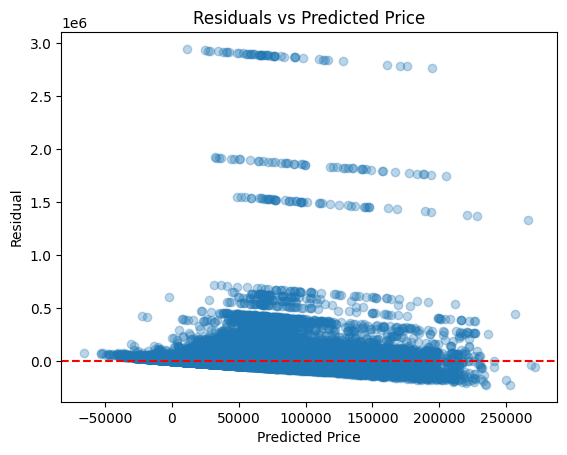

In [ ]:
residual = y_train - y_pred_OLS
plt.scatter(y_pred_OLS, residual, alpha=0.3)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title(f"Residuals vs Predicted Price")
plt.show()

In [ ]:
y_log = np.log(y_train)

ols2 = LinearRegression()
ols2.fit(X_train_clean, y_log)

LinearRegression()

In [ ]:
y_pred1 = np.exp(ols2.predict(X_train_clean))

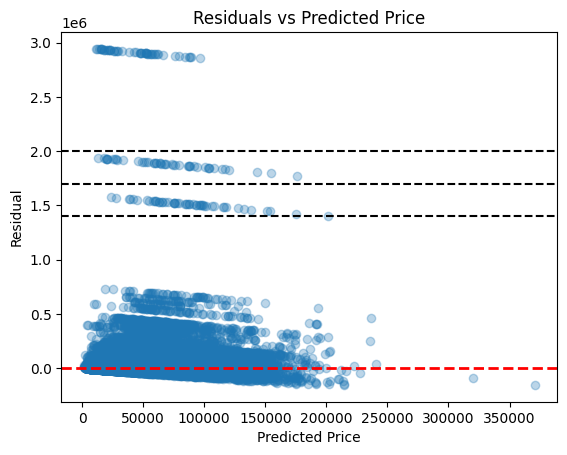

In [ ]:
residual = y_train - y_pred1
plt.scatter(y_pred1, residual, alpha=0.3)
plt.axhline(1400000, color="black", linestyle="--")
plt.axhline(1700000, color="black", linestyle="--")
plt.axhline(2000000, color="black", linestyle="--")
plt.axhline(y=5, color="red", linestyle="--", linewidth=2)
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title(f"Residuals vs Predicted Price")
plt.show()

- Perhatikan bahwa terdapat tren menurun semakin besar nilai predicted pricenya.
- Perlu dilakukan analisis lebih lanjut mengenai data point yang memiiliki nilai residual di sekitar 2.0, 1.5, dan 3.0.

In [ ]:
group_1 = residual[(residual<=2_000_000) & (residual >= 1_700_000)]
group_2 = residual[(residual<=1_700_000) & (residual >= 1_400_000)]
group_3 = residual[(residual >= 2_000_000)]

In [ ]:
df_train.loc[group_1.index]

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
id,,,,,,,,,,,,
2964,Porsche,911 R,2023,714,Gasoline,4.0L H6 24V GDI DOHC,6-Speed Manual,White,Gray,None reported,Yes,1950995
8789,Lamborghini,Gallardo LP570-4 Superleggera,2011,3254,Gasoline,5.2L V10 40V GDI DOHC,7-Speed Automatic with Auto-Shift,Nero Noctis,Nero Ade,None reported,Yes,1950995
10173,Mercedes-Benz,AMG GLS 63 4MATIC,2019,4102,Gasoline,603.0HP 4.0L 8 Cylinder Engine Gasoline Fuel,9-Speed A/T,Red,Black,None reported,Yes,1950995
21523,BMW,M3 CS,2018,7500,Gasoline,543.0HP 3.0L Straight 6 Cylinder Engine Gasoli...,Transmission w/Dual Shift Mode,Silver,Black,None reported,Yes,1950995
31429,Chevrolet,Corvette Base,2002,15443,Gasoline,400.0HP 6.0L 8 Cylinder Engine Gasoline Fuel,6-Speed A/T,Black,Beige,None reported,Yes,1950995
32645,Bentley,Continental GT Speed,2016,27981,Gasoline,6.0L W12 48V PDI DOHC Twin Turbo,8-Speed Automatic,–,Hotspur,NaN,NaN,1950995
32903,Bentley,Continental GTC Base,2012,18000,E85 Flex Fuel,552.0HP 6.0L 12 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,NaN,NaN,1950995
34801,Mercedes-Benz,SL-Class SL550 Roadster,2004,13250,Gasoline,382.0HP 5.5L 8 Cylinder Engine Gasoline Fuel,A/T,White,Beige,None reported,Yes,1950995
35218,Chevrolet,Corvette Base,2010,34500,Gasoline,400.0HP 6.0L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Blue,Blue,At least 1 accident or damage reported,Yes,1950995


In [ ]:
df_train.loc[group_2.index]

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
id,,,,,,,,,,,,
4164,Rolls-Royce,Ghost Base,2016,38800,Gasoline,563.0HP 6.7L 12 Cylinder Engine Gasoline Fuel,A/T,Black,Black,None reported,Yes,1599000
15101,Porsche,911 Carrera S,2015,7800,Gasoline,400.0HP 3.8L Flat 6 Cylinder Engine Gasoline Fuel,6-Speed M/T,White,Black,None reported,Yes,1599000
16417,Bentley,Bentayga Speed,2020,2165,Gasoline,6.0L W12 48V PDI DOHC Twin Turbo,7-Speed Automatic with Auto-Shift,Ice,Beluga Hide,None reported,Yes,1599000
17859,Land,Rover Range Rover Sport HSE,2019,5844,Gasoline,518.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,1599000
18614,Lamborghini,Huracan LP580-2,2017,22000,Gasoline,573.0HP 5.2L 10 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,White,Black,None reported,Yes,1599000
19118,BMW,M4 Base,2019,18000,Gasoline,425.0HP 3.0L Straight 6 Cylinder Engine Gasoli...,7-Speed A/T,Black,Red,None reported,Yes,1599000
19379,Tesla,Model X Performance,2023,159,NaN,778.0HP Electric Motor Electric Fuel System,A/T,Blue,Black,None reported,Yes,1599000
27807,Land,Rover Range Rover P530 SE LWB 7 Seat,2023,1538,Gasoline,523.0HP 4.4L 8 Cylinder Engine Gasoline Fuel,8-Speed A/T,Green,Green,None reported,Yes,1599000
32219,Porsche,911 GT3,2018,9712,Gasoline,4.0L H6 24V GDI DOHC,7-Speed Automatic with Auto-Shift,Gray,–,None reported,Yes,1599000


In [ ]:
df_train.loc[group_3.index]

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
id,,,,,,,,,,,,
220,Ford,F-150 XLT,2021,26315,Gasoline,3.5L V6 24V PDI DOHC Twin Turbo,10-Speed Automatic,Agate Black Metallic,Black,None reported,Yes,2954083
1880,Chrysler,300C Base,2003,55900,Gasoline,340.0HP 5.7L 8 Cylinder Engine Gasoline Fuel,5-Speed A/T,Beige,Beige,None reported,Yes,2954083
13838,Toyota,Highlander SE,2014,85000,Gasoline,3.5L V6 24V PDI DOHC,8-Speed Automatic,Green,Black,None reported,Yes,2954083
14693,Hyundai,Santa Fe SEL,2022,13865,Gasoline,2.5L I4 16V PDI DOHC,8-Speed Automatic,Black,Black,None reported,Yes,2954083
16034,Mercedes-Benz,SL-Class SL500 Roadster,2005,34068,Gasoline,302.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,7-Speed A/T,White,Beige,None reported,Yes,2954083
18946,Audi,S4 Base,2004,73500,Gasoline,340.0HP 4.2L 8 Cylinder Engine Gasoline Fuel,6-Speed M/T,Blue,Beige,None reported,Yes,2954083
21814,RAM,1500 Laramie,2022,16156,Gasoline,5.7L V8 16V MPFI OHV,8-Speed Automatic,Diamond Black,Black,None reported,NaN,2954083
36615,Ford,Excursion Limited Ultimate,2002,89900,Diesel,325.0HP 6.0L 8 Cylinder Engine Diesel Fuel,5-Speed A/T,Gold,Gold,None reported,Yes,2954083
42177,Ford,Mustang GT,2005,82000,Gasoline,300.0HP 4.6L 8 Cylinder Engine Gasoline Fuel,5-Speed M/T,Silver,Black,None reported,Yes,2954083


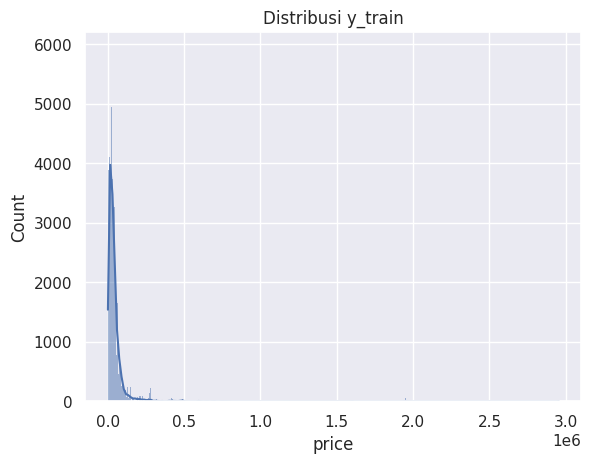

In [ ]:
sns.histplot(y_train, kde=True)
plt.title("Distribusi y_train")
plt.show()

In [ ]:
lux_car = X_train.loc[y_train[y_train> 500_000].index]
lux_car

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title
id,,,,,,,,,,,
220,Ford,F-150 XLT,2021,26315,Gasoline,3.5L V6 24V PDI DOHC Twin Turbo,10-Speed Automatic,Agate Black Metallic,Black,None reported,Yes
1204,BMW,M550 i xDrive,2018,12500,Gasoline,456.0HP 4.4L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes
1880,Chrysler,300C Base,2003,55900,Gasoline,340.0HP 5.7L 8 Cylinder Engine Gasoline Fuel,5-Speed A/T,Beige,Beige,None reported,Yes
2366,Porsche,911 Carrera S,2020,1750,Gasoline,443.0HP 3.0L Flat 6 Cylinder Engine Gasoline Fuel,8-Speed A/T,Gray,Black,None reported,Yes
2964,Porsche,911 R,2023,714,Gasoline,4.0L H6 24V GDI DOHC,6-Speed Manual,White,Gray,None reported,Yes
...,...,...,...,...,...,...,...,...,...,...,...
185530,Porsche,911 Carrera 4S,2023,9000,Gasoline,379.0HP 3.0L Flat 6 Cylinder Engine Gasoline Fuel,7-Speed A/T,White,Black,None reported,Yes
186234,Land,Rover Range Rover Sport HSE,2017,2437,Hybrid,395.0HP 3.0L Straight 6 Cylinder Engine Gasoli...,A/T,Black,Black,None reported,Yes
186598,Ford,Mustang Mach-E Premium,2023,8755,NaN,346.0HP Electric Motor Electric Fuel System,1-Speed A/T,White,Black,None reported,Yes


In [ ]:
lux_car['model'].value_counts()

,count
model,
911 GT3,10
Ghost Base,7
M4 Base,7
911 Turbo Cabriolet,7
1500 Laramie,6
...,...
Rover LR4 Lux,1
Rover Range Rover Sport Supercharged HSE,1
Mustang Mach-E Premium,1


In [ ]:
model_ctn = X_train['model'].value_counts()
model_ctn[model_ctn>1]

,count
model,
F-150 XLT,2945
M3 Base,2229
Camaro 2SS,1709
M4 Base,1622
Mustang GT Premium,1526
...,...
X5 xDrive 35i Sport Activity,2
V60 T6 R-Design Platinum,2
X3 xDrive35i,2


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X_const = add_constant(X_train_clean)

# Hitung VIF per variabel
vif = pd.DataFrame()
vif["Variable"] = X_const.columns
vif["VIF"] = [variance_inflation_factor(X_const.values, i)
              for i in range(X_const.shape[1])]

print(vif)

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                                       Variable       VIF
0                                         const  0.000000
1                                    model_year  2.629721
2                                        milage  2.182775
3                                    horsepower  3.827537
4                                   engine_size  6.111593
..                                          ...       ...
110        fuel_system_V GDI DOHC Flexible Fuel       inf
111  fuel_system_V GDI DOHC Turbo Flexible Fuel       inf
112       fuel_system_V MPFI DOHC Flexible Fuel       inf
113        fuel_system_V MPFI OHV Flexible Fuel       inf
114       fuel_system_V MPFI SOHC Flexible Fuel       inf

[115 rows x 2 columns]


In [ ]:
print("Range:", (y_train.min(), y_train.max()))

Range: (2000, 2954083)


In [ ]:
def plot_residuals_vs_features(df, y_true, y_pred, num_cols):
    residual = y_true - y_pred1
    for col in num_cols:
        plt.scatter(df[col], residual, alpha=0.3)
        plt.axhline(0, color="red", linestyle="--")
        plt.xlabel(col)
        plt.ylabel("Residual")
        plt.title(f"Residuals vs {col}")
        plt.show()

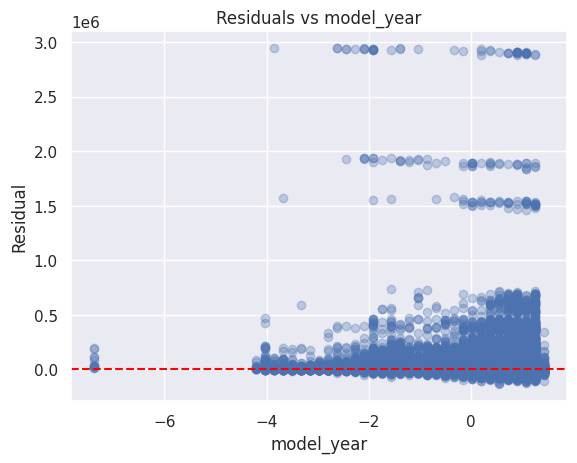

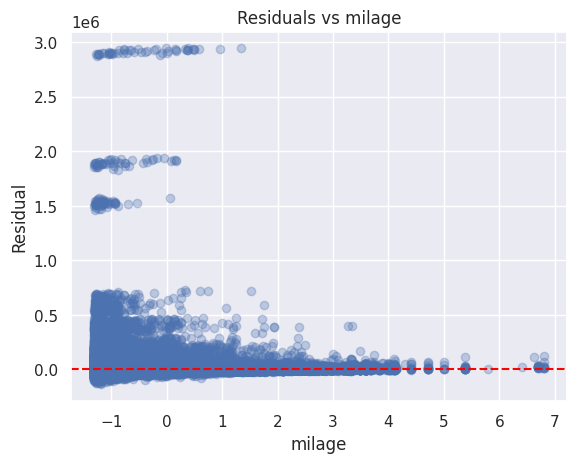

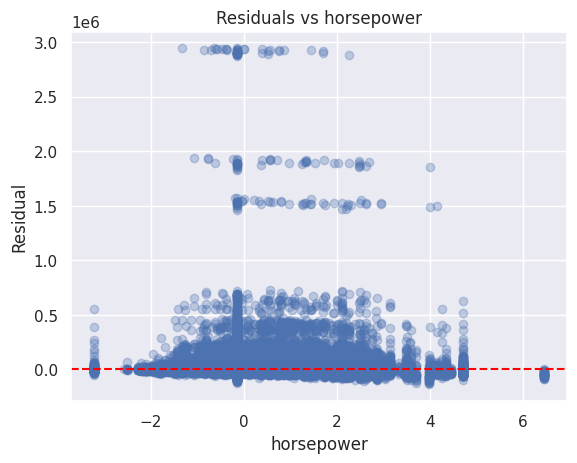

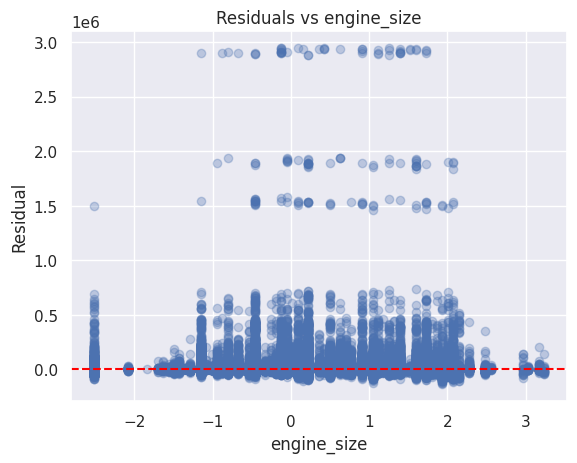

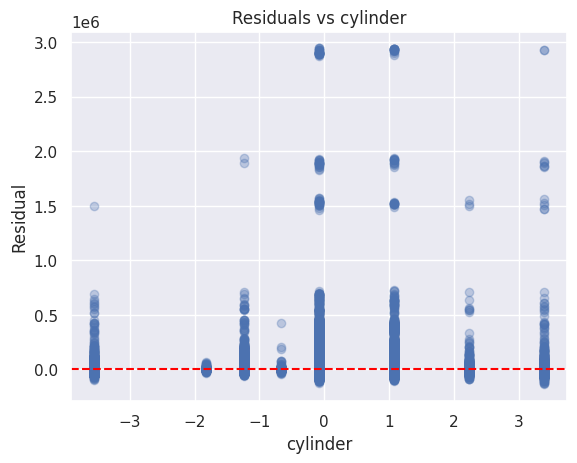

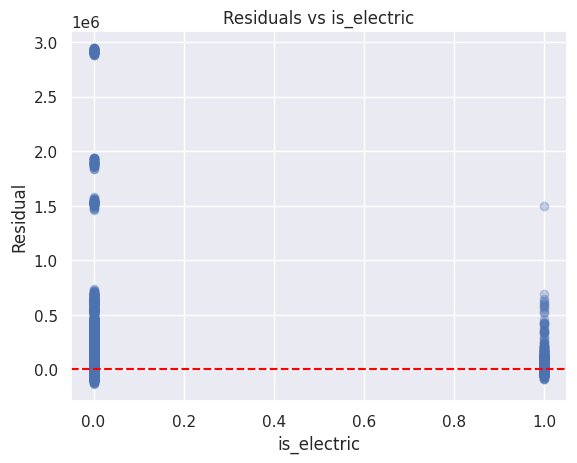

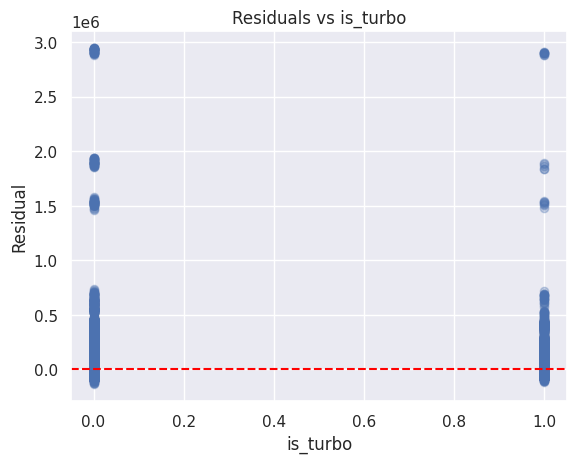

In [ ]:
plot_residuals_vs_features(X_train_clean, y_train, y_pred1, num_cols)

### Lasso Regression

In [ ]:
lasso_cv = LassoCV(alphas=[0.001, 0.01, 0.1, 1, 10], cv=5)
lasso_cv.fit(X_train_clean, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 91945890904741.56, tolerance: 94475916104.4194
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 95518921312146.31, tolerance: 94475916104.4194
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 96207279785843.38, tolerance: 94475916104.4194
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarnin

KeyboardInterrupt: 

In [ ]:
y_pred_lasso = lasso_cv.predict(X_train_clean)

### Ridge Regression

In [ ]:
ridge_cv = RidgeCV(alphas=[0.001, 0.01, 0.1, 1, 10], cv=5)
ridge_cv.fit(X_train_clean, y_train)

In [ ]:
y_pred_ridge = ridge_cv.predict(X_train_clean)

### Support Vector Regression

In [ ]:
# from sklearn.model_selection import RandomizedSearchCV
# from scipy.stats import uniform, randint
# svr = SVR()

# # param_grid = [{'kernel':['rbf'],'gamma':['scale','auto'], 'epsilon': [0.01, 0.1, 0.2, 0.5],'C': [0.1, 1, 10, 100] },
# #               {'kernel':['poly'], 'degree':[3,4,5], 'gamma':['scale','auto'],"epsilon": [0.01, 0.1, 0.2, 0.5], 'C': [0.1, 1, 10, 100]},
# #               {'kernel':['sigmoid'],'gamma':['scale','auto'], 'epsilon': [0.01, 0.1, 0.2, 0.5], 'C': [0.1, 1, 10, 100]}]
# # svr_gridsearch = GridSearchCV(estimator=svr, param_grid=param_grid, scoring = 'neg_mean_squared_error')
# # svr_gridsearch.fit(X_train_clean,  y_train)


# param_dist = {
#     "kernel": ["rbf", "poly", "sigmoid"],
#     "C": uniform(0.1, 100),        # rentang nilai C
#     "epsilon": uniform(0.01, 0.5), # rentang epsilon
#     "gamma": ["scale", "auto"],
#     "degree": randint(2, 5)        # untuk kernel poly
# }

# # Randomized Search
# svr_randomsearch = RandomizedSearchCV(
#     estimator=svr,
#     param_distributions=param_dist,
#     n_iter=20,
#     scoring="neg_mean_squared_error",
#     cv=3,
#     verbose=2,
#     n_jobs=-1,
#     random_state=42
# )

In [ ]:
# svr_randomsearch.fit(X_train_clean,y_train)

### Decision Tree Regressor

In [ ]:
from sklearn.tree import DecisionTreeRegressor

In [ ]:
dt_reg = DecisionTreeRegressor()
param_grid = {
    "max_depth": [None, 5, 10, 20],          # batas kedalaman pohon
    "min_samples_split": [2, 5, 10],         # minimum sampel utk split
    "min_samples_leaf": [1, 2, 4],           # minimum sampel di daun
    "max_features": [None, "sqrt", "log2"]   # jumlah fitur yg dipertimbangkan
}

dt_gridsearch = GridSearchCV(
    estimator=dt_reg,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    scoring="neg_mean_squared_error"
)

In [ ]:
dt_gridsearch.fit(X_train_clean, y_train)

In [ ]:
y_pred_dt = dt_gridsearch.predict(X_train_clean)

### KNN Regressor

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

In [ ]:
knn = KNeighborsRegressor()
# param_grid = {
#     'n_neighbors': [3, 5, 7, 9, 11],        # jumlah tetangga
#     'weights': ['uniform', 'distance'],     # bobot
#     'metric': ['euclidean', 'manhattan', 'minkowski'],  # metrik jarak
#     'p': [1, 2]                             # 1 = manhattan, 2 = euclidean (untuk minkowski)
# }

# # Grid search
# knn_gridsearch = GridSearchCV(knn, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, verbose=2)

In [ ]:
# knn_gridsearch.fit(X_train_clean, y_train)

In [ ]:
knn.fit(X_train_clean,y_train)

In [ ]:
y_pred_knn = knn.predict(X_train_clean)

### Adaboost

In [ ]:
from sklearn.ensemble import AdaBoostRegressor

In [ ]:
ada_reg = AdaBoostRegressor()
ada_reg.fit(X_train_clean, y_train)

In [ ]:
y_pred_ada = ada_reg.predict(X_train_clean)

## XGBoost

In [ ]:
from xgboost import XGBRegressor

In [ ]:
xgb_reg = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb_reg.fit(X_train_clean, y_train)
y_pred_xgb = xgb_reg.predict(X_valid_clean)
print("RMSE: ", np.sqrt(mean_squared_error(y_valid, y_pred_xgb)))

RMSE:  69630.01100100444


### Randomized Parameter Search

In [ ]:
xgb = XGBRegressor(random_state=42)

param_dist_xgb = {
    "n_estimators": [200, 500, 800],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

search_xgb = RandomizedSearchCV(
    xgb, param_distributions=param_dist_xgb,
    n_iter=10, cv=3, scoring="neg_root_mean_squared_error",
    n_jobs=-1, random_state=42
)
search_xgb.fit(X_train_clean, y_train)
best_xgb = search_xgb.best_estimator_

In [ ]:
y_pred_xgb_ = best_xgb.predict(X_valid_clean)
print("RMSE: ", np.sqrt(mean_squared_error(y_valid, y_pred_xgb_)))

RMSE:  69506.41984737813


In [ ]:
save_model(best_xgb, filename="xgb_randomized.pkl")

Model berhasil disimpan ke xgb_randomized.pkl


## CatBoost

In [ ]:
!pip install catboost

from catboost import CatBoostRegressor

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 5.9 MB/s eta 0:00:00


In [ ]:
cat_reg = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=4,
    verbose=0,
    random_state=42
)

cat_reg.fit(X_train_clean, y_train)
y_pred_cat = cat_reg.predict(X_valid_clean)

print("CatBoost RMSE:", np.sqrt(mean_squared_error(y_valid, y_pred_cat)))

CatBoost RMSE: 69379.740466527


### Randomized Parameter Search

In [ ]:
cat = CatBoostRegressor(verbose=0, random_state=42)

param_dist_cat = {
    "iterations": [200, 500, 800],
    "learning_rate": [0.01, 0.05, 0.1],
    "depth": [4, 6, 8],
    "l2_leaf_reg": [1, 3, 5]
}

search_cat = RandomizedSearchCV(
    cat, param_distributions=param_dist_cat,
    n_iter=10, cv=3, scoring="neg_root_mean_squared_error",
    n_jobs=-1, random_state=42
)
search_cat.fit(X_train_clean, y_train)
best_cat = search_cat.best_estimator_

In [ ]:
y_pred_cat_ = best_cat.predict(X_valid_clean)
print("RMSE: ", np.sqrt(mean_squared_error(y_valid, y_pred_cat_)))

RMSE:  69422.57899201386


In [ ]:
save_model(best_cat, filename="cat_randomized.pkl")

Model berhasil disimpan ke cat_randomized.pkl


## LGBM

In [ ]:
from lightgbm import LGBMRegressor

In [ ]:
lgb_reg = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42
)

lgb_reg.fit(X_train_clean, y_train)
y_pred_lgb = lgb_reg.predict(X_valid_clean)

print("LightGBM RMSE:", np.sqrt(mean_squared_error(y_valid, y_pred_lgb)))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.046983 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 780
[LightGBM] [Info] Number of data points in the train set: 169679, number of used features: 100
[LightGBM] [Info] Start training from score 43888.560718
LightGBM RMSE: 69788.42211763008


### Randomized Parameter Search

In [ ]:
lgb = LGBMRegressor(random_state=42)

param_dist_lgb = {
    "n_estimators": [200, 500, 800],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, -1],
    "num_leaves": [31, 63, 127],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

search_lgb = RandomizedSearchCV(
    lgb, param_distributions=param_dist_lgb,
    n_iter=10, cv=3, scoring="neg_root_mean_squared_error",
    n_jobs=-1, random_state=42
)
search_lgb.fit(X_train_clean, y_train)
best_lgb = search_lgb.best_estimator_

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.072521 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 780
[LightGBM] [Info] Number of data points in the train set: 169679, number of used features: 100
[LightGBM] [Info] Start training from score 43888.560718
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

In [ ]:
y_pred_lgb_ = best_lgb.predict(X_valid_clean)
print("RMSE: ", np.sqrt(mean_squared_error(y_valid, y_pred_lgb_)))

RMSE:  69242.2220949835


In [ ]:
save_model(best_lgb, filename="lgb_randomized.pkl")

Model berhasil disimpan ke lgb_randomized.pkl


# Model Evaluation

In [ ]:
preds = {"Linear Regression": y_pred_OLS,
         "Lasso Regression": y_pred_lasso,
         "Ridge Regression": y_pred_ridge,
         "KNN Regression": y_pred_knn,
         "Decision Tree": y_pred_dt,
         "Adaboost":y_pred_ada}

In [ ]:
def evaluate_models(y_true, predictions: dict):
    """
    Evaluasi hasil prediksi dari beberapa model menggunakan RMSE.

    Parameters:
    -----------
    y_true : array-like
        Nilai sebenarnya (ground truth).
    predictions : dict
        Dictionary dengan format {"nama_model": y_pred}.

    Returns:
    --------
    DataFrame berisi RMSE tiap model.
    """
    results = []

    for model_name, y_pred in predictions.items():
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        results.append({"Model": model_name, "RMSE": rmse})

    return pd.DataFrame(results).sort_values(by="RMSE", ascending=True).reset_index(drop=True)

In [ ]:
result = evaluate_models(y_train, preds)

In [ ]:
result

# prediction

In [ ]:
X_test_clean = preprocessing_pipeline(df_test, imp, scaler, OHencoder)

/tmp/ipython-input-288801657.py:10: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  X.loc[trans_series.str.contains(r'(a\/t|at|automatic|auto[-\s]?shift|cvt|dct|\d+\s*[-]?\s*speed\s*(a\/t|at|automatic))', regex=True, na=False), 'transmission'] = "a/t"
/tmp/ipython-input-288801657.py:11: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  X.loc[trans_series.str.contains(r'(m\/t|mt|manual|\d+\s*[-]?\s*speed\s*(m\/t|mt|manual))', regex=True, na=False), 'transmission'] = "m/t"
/tmp/ipython-input-595397083.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when do

In [ ]:
y_test_pred = knn.predict(X_test_clean)

In [ ]:
result_knn = pd.DataFrame({"id": X_test_clean.index, "price": y_test_pred})

In [ ]:
result_knn.to_csv("result_knn.csv", index=False)

In [ ]:
y_test_pred = dt_gridsearch.predict(X_test_clean)

In [ ]:
result_dt = pd.DataFrame({"id": X_test_clean.index, "price": y_test_pred})

In [ ]:
result_dt.to_csv("result_dt.csv", index=False)

## Cat_reg prediction on test data

In [ ]:
y_test_pred = cat_reg.predict(X_test_clean)
result_cat = pd.DataFrame({'id': X_test_clean.index, "price": y_test_pred})
result_cat.to_csv("result_cat.csv", index = False)

LGBM Prediction on test data

In [ ]:
y_test_pred = best_lgb.predict(X_test_clean)
result_lgb = pd.DataFrame({'id': X_test_clean.index, "price": y_test_pred})
result_lgb.to_csv("result_lgbm.csv", index = False)

In [ ]:
# def predict(model, data):
#   y_pred = model.predict(data)
#   result_df = pd.DataFrame({"id": data.index, "price": y_pred})
#   return result_df

In [ ]:
# y_test_pred1 = OLS_reg.predict(X_test_clean)

In [ ]:
# y_test_pred2 = Lasso_reg.predict(X_test_clean)

In [ ]:
# y_test_pred3 = lasso_cv.predict(X_test_clean)

In [ ]:
# result1 = pd.DataFrame({"id": X_test_clean.index, "price": y_test_pred1})
# result2 = pd.DataFrame({"id": X_test_clean.index, "price": y_test_pred2})
# result3 = pd.DataFrame({"id": X_test_clean.index, "price": y_test_pred3})

In [ ]:
# result1

In [ ]:
# result1.to_csv("result1.csv", index=False)
# result2.to_csv("result2.csv", index=False)
# result3.to_csv("result3.csv", index=False)

In [ ]:
# files.download("result1.csv")
# files.download("result2.csv")
# files.download("result3.csv")